# STIX Lightcurve Analysis Pipeline

This notebook provides a complete workflow for analysing time series such as STIX lightcurves.  
Whilst the notebook provides the means to download the necessary data, the user can also choose to use their own data and thus skip the data acquisition and preparation steps.

The pipeline consists of the following stages:

1. **Data Acquisition** -- Downloading files within a chosen time interval  
2. **Data Preparation** -- Selecting the energy range and time interval of the time series, and providing a time stamp for background reduction  
3. **Smoothing** -- Choice between Gaussian Process Regression (a machine learning algorithm) and a running mean (with window size determined by a $\chi^2$ best fit)  
4. **Decomposition Analysis** -- The smoothed profile is decomposed into multiple curve components (shape determined by a $\chi^2$ best fit: Lorentzian, Gaussian, or asymmetric Gaussian) based on [Gaussian decomposition tool](https://github.com/hannahc243/Gaussian_Decomp.git)  
5. **Comparison to** [AFINO](https://afino-release-version.readthedocs.io/en/latest/) **and** [Wavelet Analysis](https://github.com/ct6502/wavelets)

In [1]:
# module imports
from pathlib import Path
from sunpy.net import Fido, attrs as a
import numpy as np
from astropy.io import fits
from stixpy.product import Product
import os
from astropy.time import Time
from data_processing import cal_data
from user_functions import *
import matplotlib.pyplot as plt
from Gaussian_Decomp.gaussian_decomp_start import *
from Gaussian_Decomp.gp_regression import *
import pandas as pd
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
import afino.afino_start as af
from wave_python import wavelet_analysis_soler_workflow as wvlt

/home/jmitchell/anaconda3/envs/soler_workshop_imaging_timeseries/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Data Acquisition

**SKIP THIS STEP IF YOU HAVE ALREADY ACQUIRED YOUR DATA**

Choose a time interval of interest for the analysis. Bey default, this notebook will look for the latest version of the STIX cpd files within this window.

In [2]:
# Setting up folder structure (save status off by default)
fetchfolder = Path('sci_data')
fetchfolder.mkdir(exist_ok=True, parents=True)

# Define search parameters
start_time = '2024-08-05T12:00:00'
end_time = '2024-08-05T15:00:00'
time = a.Time(start_time, end_time)
instrument = a.Instrument.stix
product = a.stix.DataProduct.sci_xray_cpd	

# Search + latest version
resp = Fido.search(instrument, time, product)
sci_table = resp['stix']
sci_table.filter_for_latest_version()
sci_table

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str12,str3,int64
2024-08-05T12:01:23.000,2024-08-05T12:16:53.000,STIX,L1,SCI,sci-xray-cpd,V02,2408052438
2024-08-05T12:36:32.000,2024-08-05T12:43:30.000,STIX,L1,SCI,sci-xray-cpd,V02,2408053125
2024-08-05T12:52:12.000,2024-08-05T12:58:54.000,STIX,L1,SCI,sci-xray-cpd,V02,2408058780
2024-08-05T13:00:29.000,2024-08-05T13:08:29.000,STIX,L1,SCI,sci-xray-cpd,V02,2408057214
2024-08-05T13:07:40.000,2024-08-05T13:24:29.000,STIX,L1,SCI,sci-xray-cpd,V02,2408054287
2024-08-05T13:22:29.000,2024-08-05T13:46:06.000,STIX,L1,SCI,sci-xray-cpd,V02,2408052130
2024-08-05T13:43:03.000,2024-08-05T14:14:58.000,STIX,L1,SCI,sci-xray-cpd,V02,2408057564
2024-08-05T14:14:32.000,2024-08-05T16:44:16.000,STIX,L1,SCI,sci-xray-cpd,V02,2408053314


The notebook automatically downloads all available files within the selected interval and filters for the highest time resolution. If a different file is desired, you can manually select it by changing the index (`idx`) in the following code block.

In [3]:
# Download all files
files = Fido.fetch(sci_table, path=str(fetchfolder / '{file}'))

# Filter for highest cadence
cadence = []    
filtered_files = []
filtered_rows = []  
for row, fname in zip(sci_table, files):
    hdul = fits.open(fname)
    hdr = int(hdul[0].header['XPOSURE'])
    hdul.close()
    cpd = Product(fname)
    mask_sum = np.sum(cpd.detector_masks.masks)
    filtered_files.append(fname)
    filtered_rows.append(row)
    cadence.append(hdr)
idx = int(np.argmin(cadence))
sci_data = files[idx] # change this index to select different file

Files Downloaded:   0%|          | 0/8 [00:00<?, ?file/s]
































Files Downloaded:  12%|█▎        | 1/8 [00:00<00:03,  1.86file/s]








Files Downloaded:  25%|██▌       | 2/8 [00:00<00:01,  3.53file/s]

































































Files Downloaded:  50%|█████     | 4/8 [00:01<00:01,  2.19file/s]



































































































































































































































































































Files Downloaded:  62%|██████▎   | 5/8 [00:07<00:06,  2.01s/file]























































































































































































































































































































































# 2. Data Preparation

**Skip this step if you have already prepared your data.**

The desired energy range can be adjusted by manually setting the arguments `e_min` and `e_max`. Note that some lightcurves may contain no counts above a certain threshold, so choosing too high a minimum energy can result in empty data. Adjust the range accordingly.

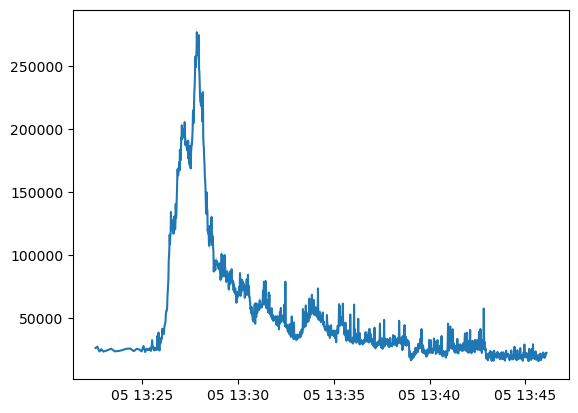

In [4]:
time, counts, time_dt, error = cal_data(sci_data=sci_data,
                                        bkg_data=sci_data,
                                        e_min=25,
                                        e_max=None,
                                        t_sci=None,
                                        t_bkg=None,
                                        save_csv=False)
plt.plot(time_dt, counts)
counts_low = counts - error
counts_high = counts + error
plt.fill_between(time_dt, counts_low, counts_high, alpha=0.5)


Select the time interval for your region of interest (`time_sci`) and a relatively quiet interval prior to the flare for background subtraction (`time_bkg`). Alternatively, a separate file can be used for background estimation.

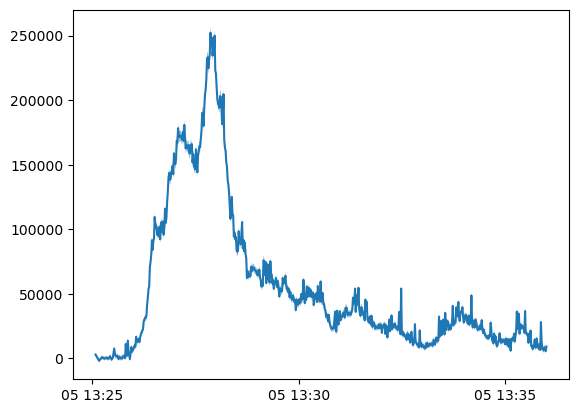

In [5]:
sci_start = Time('2024-08-05T13:25:00')
sci_end = Time('2024-08-05T13:36:00')
time_sci = (sci_start, sci_end)

bkg_start = Time('2024-08-05T13:22:00')
bkg_end = Time('2024-08-05T13:24:00')
time_bkg = (bkg_start, bkg_end)

time, counts, time_dt, yerr = cal_data(sci_data=sci_data,
                                        bkg_data=sci_data,
                                        e_min=25,
                                        e_max=None,
                                        t_sci=time_sci,
                                        t_bkg=time_bkg,
                                        save_csv=False)
plt.plot(time_dt, counts)
counts_low = counts - yerr
counts_high = counts + yerr
plt.fill_between(time_dt, counts_low, counts_high, alpha=0.5)

# 3. Data Smoothing

**If you have already obtained your desired time series, use this step to input arrays for count rate, time, and associated uncertainties.**

Choose between the following methods:

- **Gaussian Process Smoothing (`gp`)** -- Smoothing parameters are determined via hyperparameter optimisation. This process may take a few minutes but typically results in a smooth and well-behaved curve profile.  
- **Running Mean (`rm`)** -- The curve is smoothed using a moving average, where the window size is determined using a reduced $\chi^2$ criterion.

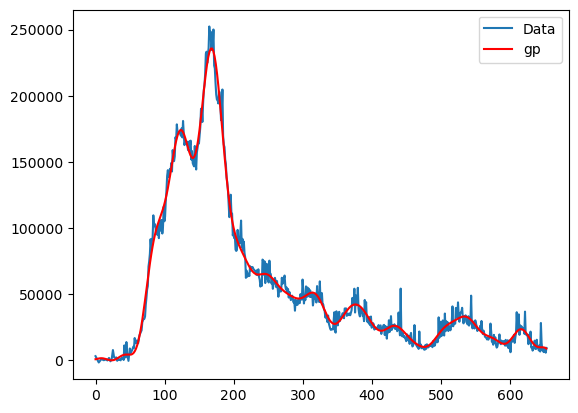

In [6]:
# Setting up save paths and parameters for decomposition

smoothing = 'gp'
params = {"alpha": np.arange(0.005, 0.015, 0.001), 
    "kernel": [ConstantKernel(k, constant_value_bounds="fixed")*RBF(l, length_scale_bounds="fixed") for l in np.arange(0.01,0.2,0.01) for k in np.arange(1,4,0.1)]}

# Use counts from this analysis or from your own pre-processing
# file = Path('input_data/2024-08-05T13-25-04_2408052130.csv')
# df = pd.read_csv(file)
# counts= np.asarray(df['counts'])
# time  = np.asarray(df['time'])
# yerr = np.asarray(df['yerr'])

counts = np.asarray(counts)
time  = np.asarray(time)
yerr = np.asarray(yerr)

if smoothing == 'gp':
    best_score, best_params = hyperparam_opt(time, counts, params)
    alpha = best_params['alpha']
    ker_amplitude = best_params['kernel'].k1.constant_value**2
    length_scale = best_params['kernel'].k2.length_scale
    x_inv, smoothed, errors = gp_regression(time, counts, alpha, ker_amplitude, length_scale)

elif smoothing == 'rm':
    alpha, ker_amplitude, length_scale = None, None, None
    x_inv, smoothed, errors = running_mean_chi2(time, counts, yerr)

plt.plot(time, counts, label='Data')
plt.plot(x_inv, smoothed, 'r-', label=smoothing)
plt.legend()

# 4. Decomposition

This is the main stage of the analysis. The lightcurve is decomposed into multiple curve components. The preferred model is selected using a reduced $\chi^2$ criterion, but this can be overridden by setting `model` to `gaussian`, `lorentzian`, or `asymmetric_gaussian`.

Additional configurable parameters include:

- **Maximum number of components (`max_comp`)** -- Only the largest *n* components are retained for fitting  
- **Minimum width (`min_width`)** -- Prevents fitting of very narrow peaks that may arise from noise or artefacts  

The time of each peak is also determined. A linear fit to these peak times is performed, where the slope provides an estimate of the periodicity of the analysed lightcurve.

Best model: lorentzian, chi^2 = 1620783.047


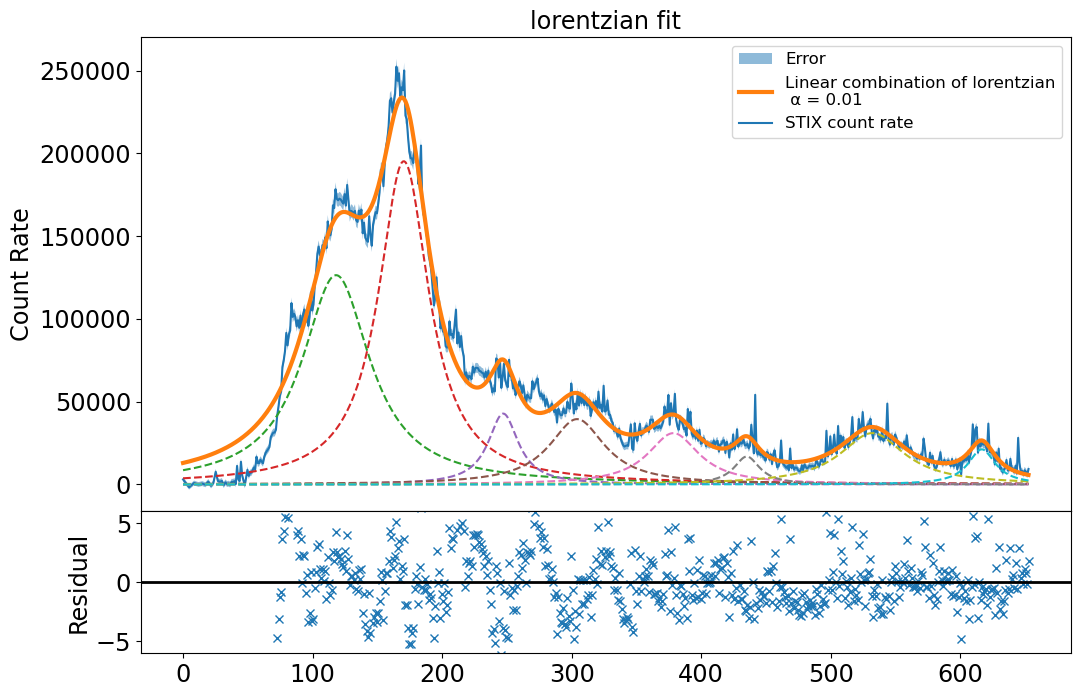

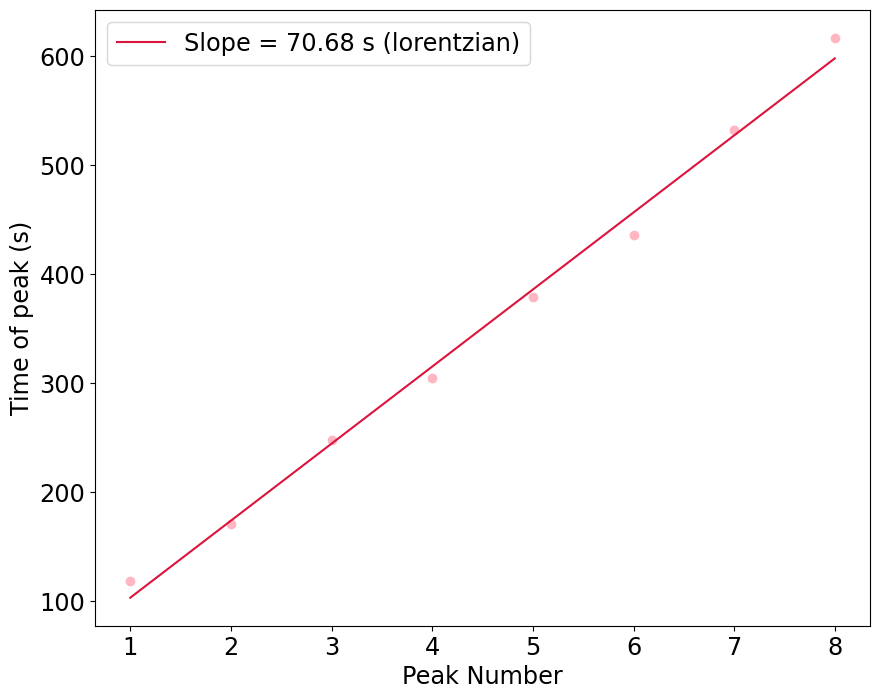

Analysis summary 
-----------------
 Best model: lorentzian
 Number of components: 8.0
 Slope of Line Fit: 70.7 s
 Pearson correlation coefficient, pvalue: 0.997, 6.461853237780266e-08
 Residual std: 4.08


In [7]:
best_model, fit, popt, resid_std, slope = analyse_series(time=time,
               counts=counts, 
               length_scale=length_scale, 
               time_format=None,
               frac_t=0.2, frac_v=0.35, frac_w=0.3,
               thresh_peak=0.25,
               smoothing=smoothing,
               yerr=yerr,
               alpha=alpha, 
               ker_amplitude=ker_amplitude, 
               string=None,
               savedir=None,
               description=None,
               max_comp=None,
               min_width=None,
               model=None
            )

# 5. Comparison to Other Models

This step compares the derived period with results from established methods: [AFINO](https://afino-release-version.readthedocs.io/en/latest/) and [Wavelet Analysis](https://github.com/ct6502/wavelets).

In the summary plot (second figure, bottom right), the period obtained from AFINO is shown in green and is dashed when no quasi-periodic behaviour is detected. The orange dashed line represents the global confidence level from the wavelet analysis, which also provides an indication of quasi-periodic behaviour.

For a more detailed explanation of these methods, see *[The Automated Flare Inference of Oscillations (AFINO) catalogue](https://aringlis.github.io/AFINO/)* and *[A Practical Guide to Wavelet Analysis](https://paos.colorado.edu/research/wavelets/bams_79_01_0061.pdf)*.

 
Analysis summary info:
-----------------------------
 
Lnlike m0 (pow_const): 1631.6249534793783
Lnlike m1 (pow_const_gauss): 1634.2250071160852
Lnlike m2 (bpow_const): 1634.576296665383
 
BIC m0 (pow_const): -3251.7384225315827
BIC m1 (pow_const_gauss): -3239.6713031642357
BIC m2 (bpow_const): -3246.1296244764185
 
rchi2 m0 (pow_const): 0.9533060290001253
prob. m0 (pow_const): 0.5962958307779354
rchi2 m1 (pow_const_gauss): 0.962018320499563
prob. m1 (pow_const_gauss): 0.5738624236005195
rchi2 m2 (bpow_const): 0.9575330352004867
prob. m2 (bpow_const): 0.5852943415800629
 
-----------------------------
 
 


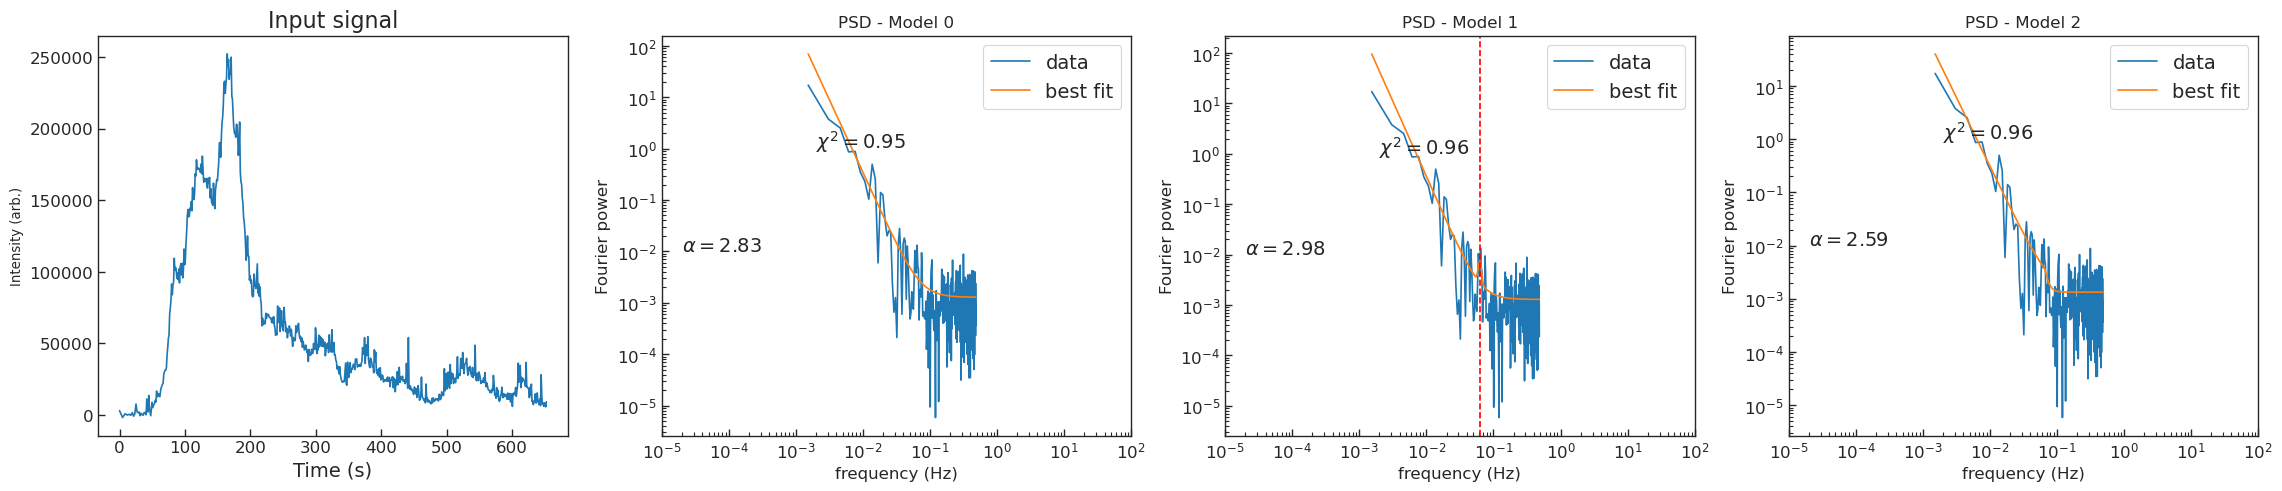

In [8]:
af_qpp_det, af_qpp = af.analyse_series(time, counts, 
                                       description=None, savedir=None)

In [9]:
best_model

'lorentzian'

lag1 =  0.72


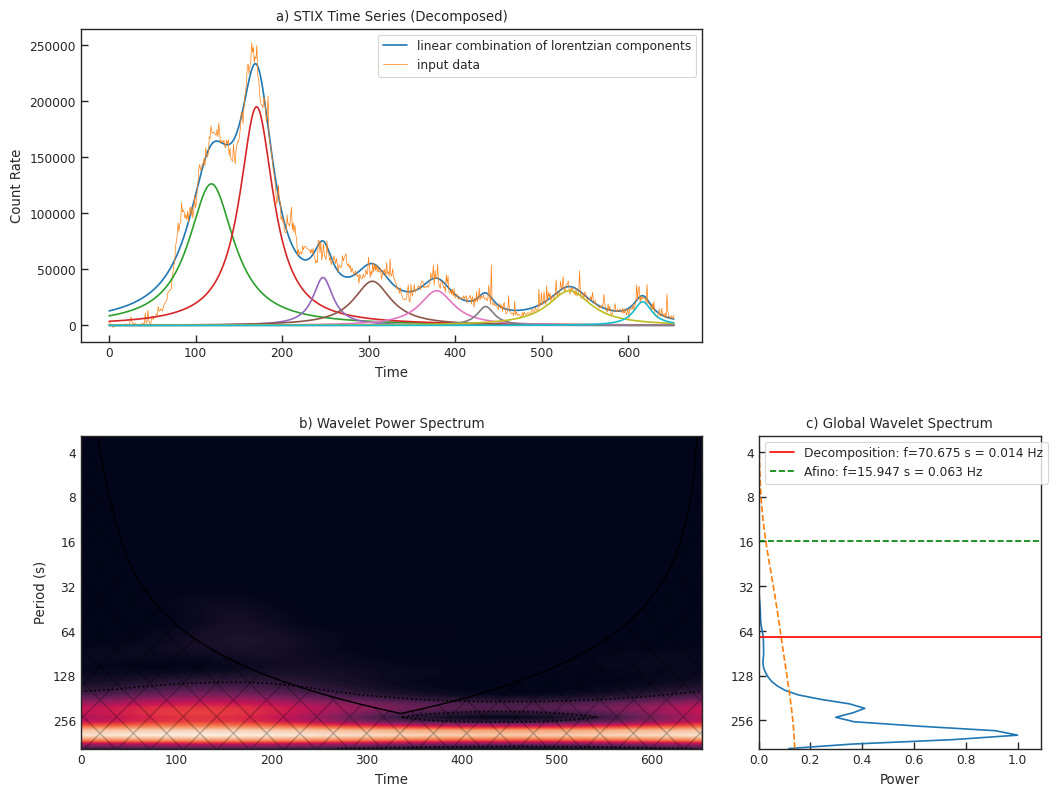

In [11]:
wvlt.analyse_series(
                    time=time, fit=fit, counts=counts, slope=slope, model=best_model, popt=popt,
                    afino_status=af_qpp_det, afino_period=af_qpp
                    )